## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    make_scorer
)
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb
import optuna
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')

%matplotlib inline

RANDOM_STATE = 42
N_FOLDS = 5
np.random.seed(RANDOM_STATE)

---
## 2. Load Data & Feature Selection

In [2]:
df = pd.read_csv(Path('../../data/claims_cleaned.csv'))
print(f'Loaded dataset: {df.shape}')
print(f'Target distribution: {df["target"].value_counts().to_dict()}')

Loaded dataset: (2880, 67)
Target distribution: {1: 2427, 0: 453}


In [ ]:
# Features to DROP — zero/near-zero variance or redundant (see 02_ml_model_plan.md)
DROP_FEATURES = [
    'deviceCost',              # all zeros
    'balance_change',          # all zeros (balanceRRP == oldBalanceRRP)
    'has_balance_change',      # derived from above — all zeros
    'oldBalanceRRP',           # identical to balanceRRP
    'balanceRRP',              # near-perfect correlation with rrp — drop to avoid multicollinearity
    'smashed',                 # always 0 when assessed
    'frontOrBackCamera',       # always 0 when assessed
    'other',                   # text field wrongly treated as boolean — all -1
    'relationship_encoded',    # single value ("self") for all rows
    'buttons',                 # 99.7% zero
    'connection',              # 99.95% zero
    'charging',                # 99.95% zero
]

# Load the full feature list from EDA, then remove dead features
with open(Path('../../data/feature_columns.txt'), 'r') as f:
    all_features = [line.strip() for line in f.readlines()]

feature_cols = [f for f in all_features if f not in DROP_FEATURES]
print(f'Features: {len(all_features)} -> {len(feature_cols)} (dropped {len(all_features) - len(feature_cols)})')
print(f'\nFinal features ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

Features: 45 -> 33 (dropped 12)

Final features (33):
   1. excessFee
   2. rrp
   3. excess_to_rrp_ratio
   4. device_condition_score
   5. device_issues_count
   6. device_not_assessed_count
   7. turnOnOff
   8. touchScreen
   9. frontCamera
  10. backCamera
  11. audio
  12. mic
  13. desc_length
  14. desc_word_count
  15. desc_sentence_count
  16. desc_has_newlines
  17. desc_uppercase_ratio
  18. desc_exclamation_count
  19. desc_question_count
  20. has_redacted_pii
  21. policy_duration_days
  22. purchase_to_policy_days
  23. is_policy_active
  24. policy_start_month
  25. policy_start_dayofweek
  26. coverage_encoded
  27. claimType_encoded
  28. country_encoded
  29. channel_encoded
  30. deviceType_encoded
  31. productCode_freq
  32. retailerName_freq
  33. model_freq


In [4]:
X = df[feature_cols].values
y = df['target'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {np.bincount(y)} (0=Declined, 1=Completed)')
print(f'Imbalance ratio: {np.sum(y==1) / np.sum(y==0):.2f}:1')

X shape: (2880, 33)
y shape: (2880,)
Class balance: [ 453 2427] (0=Declined, 1=Completed)
Imbalance ratio: 5.36:1


---
## 3. Evaluation Helpers

In [5]:
def evaluate_cv(model, X, y, feature_names=None, model_name='Model', n_folds=N_FOLDS):
    """Run stratified K-fold CV and print comprehensive metrics."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        
        f1_macro = f1_score(y_val, y_pred, average='macro')
        f1_declined = f1_score(y_val, y_pred, pos_label=0)
        pr_auc = average_precision_score(y_val, y_proba)
        roc = roc_auc_score(y_val, y_proba)
        
        fold_metrics.append({
            'fold': fold+1, 'f1_macro': f1_macro, 'f1_declined': f1_declined,
            'pr_auc': pr_auc, 'roc_auc': roc
        })
        
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)
    
    metrics_df = pd.DataFrame(fold_metrics)
    
    print(f'\n{"="*60}')
    print(f'{model_name} — {n_folds}-Fold Stratified CV Results')
    print(f'{"="*60}')
    print(f'\nPer-fold metrics:')
    print(metrics_df.to_string(index=False))
    print(f'\nMean +/- Std:')
    for col in ['f1_macro', 'f1_declined', 'pr_auc', 'roc_auc']:
        print(f'  {col:15s}: {metrics_df[col].mean():.4f} +/- {metrics_df[col].std():.4f}')
    
    # Aggregate classification report
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.array(all_y_proba)
    
    print(f'\nAggregate Classification Report (all folds):')
    print(classification_report(all_y_true, all_y_pred, 
                                target_names=['Declined', 'Completed']))
    
    return {
        'metrics_df': metrics_df,
        'y_true': all_y_true,
        'y_pred': all_y_pred,
        'y_proba': all_y_proba,
    }

In [6]:
def plot_evaluation(results, model_name='Model'):
    """Plot confusion matrix and precision-recall curve."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion matrix
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Declined', 'Completed']).plot(ax=axes[0], cmap='Blues')
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    
    # Precision-Recall curve
    PrecisionRecallDisplay.from_predictions(
        results['y_true'], results['y_proba'], ax=axes[1], name=model_name
    )
    axes[1].set_title(f'{model_name} — Precision-Recall Curve')
    
    # Predicted probability distribution by class
    for label, name in [(0, 'Declined'), (1, 'Completed')]:
        mask = results['y_true'] == label
        axes[2].hist(results['y_proba'][mask], bins=30, alpha=0.5, label=name, density=True)
    axes[2].set_xlabel('Predicted P(Completed)')
    axes[2].set_ylabel('Density')
    axes[2].set_title(f'{model_name} — Probability Distribution')
    axes[2].legend()
    axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

---
## 4. Model A — Logistic Regression (Baseline)

In [7]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

lr_results = evaluate_cv(lr_model, X, y, model_name='Logistic Regression (Baseline)')


Logistic Regression (Baseline) — 5-Fold Stratified CV Results

Per-fold metrics:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.537764     0.317881 0.901261 0.657819
    2  0.492213     0.277108 0.872180 0.583048
    3  0.532808     0.319489 0.924610 0.679529
    4  0.506049     0.274510 0.875390 0.579404
    5  0.525210     0.327381 0.897776 0.620528

Mean +/- Std:
  f1_macro       : 0.5188 +/- 0.0191
  f1_declined    : 0.3033 +/- 0.0253
  pr_auc         : 0.8942 +/- 0.0214
  roc_auc        : 0.6241 +/- 0.0445

Aggregate Classification Report (all folds):
              precision    recall  f1-score   support

    Declined       0.21      0.53      0.30       453
   Completed       0.88      0.63      0.73      2427

    accuracy                           0.62      2880
   macro avg       0.55      0.58      0.52      2880
weighted avg       0.77      0.62      0.67      2880



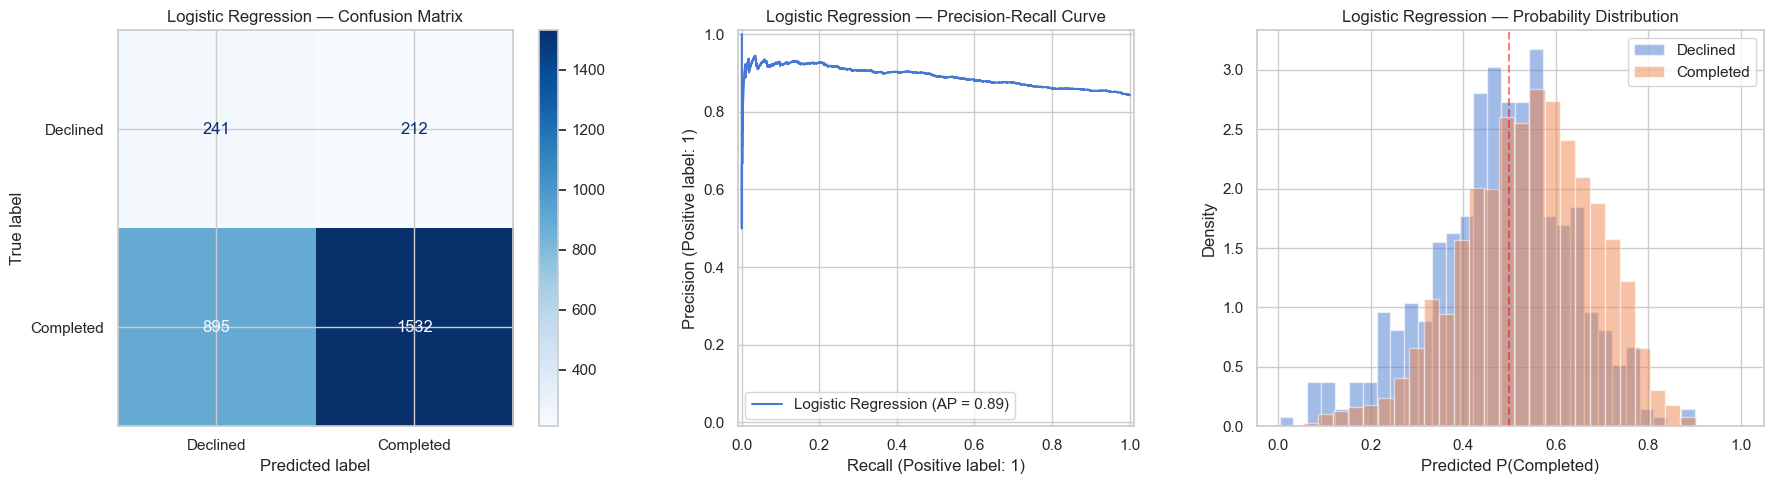

In [8]:
plot_evaluation(lr_results, 'Logistic Regression')

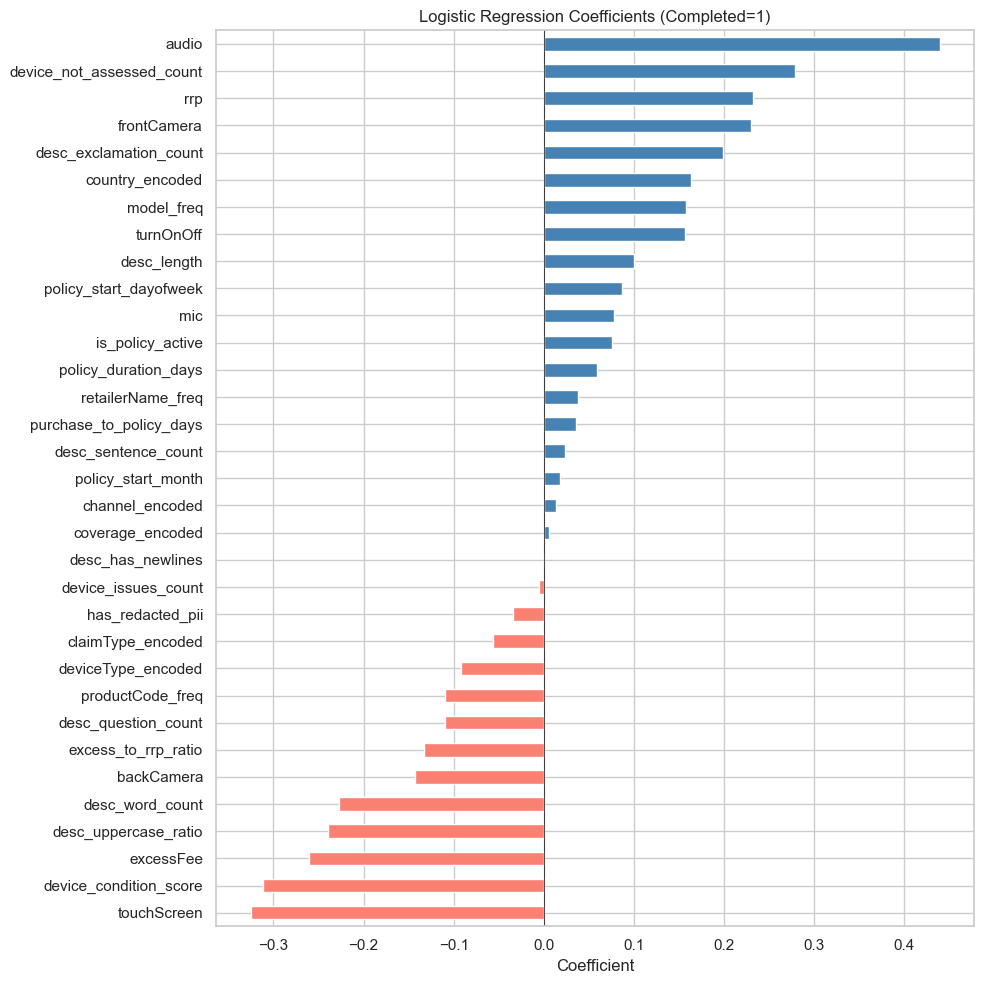

In [9]:
# Logistic Regression coefficients — feature importance
lr_model.fit(X, y)
coefs = pd.Series(
    lr_model.named_steps['clf'].coef_[0],
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
coefs.plot(kind='barh', ax=ax, color=coefs.apply(lambda x: 'salmon' if x < 0 else 'steelblue'))
ax.set_title('Logistic Regression Coefficients (Completed=1)')
ax.set_xlabel('Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 5. Model B — LightGBM (Default, Pre-Tuning)

In [10]:
# Imbalance ratio for scale_pos_weight
neg_count = np.sum(y == 0)
pos_count = np.sum(y == 1)
imbalance_ratio = neg_count / pos_count
print(f'Imbalance ratio (neg/pos): {imbalance_ratio:.4f}')
print(f'scale_pos_weight for "Declined is minority": {pos_count / neg_count:.4f}')
# Note: target=1 means Completed (majority). Declined=0 is the minority.
# LightGBM's is_unbalanced=True handles this automatically.

Imbalance ratio (neg/pos): 0.1867
scale_pos_weight for "Declined is minority": 5.3576


In [11]:
lgb_default = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_default_results = evaluate_cv(lgb_default, X, y, model_name='LightGBM (Default)')


LightGBM (Default) — 5-Fold Stratified CV Results

Per-fold metrics:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.559908     0.268041 0.868149 0.587540
    2  0.532424     0.219895 0.863625 0.570930
    3  0.615651     0.371429 0.914909 0.705064
    4  0.558814     0.263158 0.886457 0.629342
    5  0.561772     0.277228 0.885423 0.614977

Mean +/- Std:
  f1_macro       : 0.5657 +/- 0.0304
  f1_declined    : 0.2800 +/- 0.0557
  pr_auc         : 0.8837 +/- 0.0202
  roc_auc        : 0.6216 +/- 0.0520

Aggregate Classification Report (all folds):
              precision    recall  f1-score   support

    Declined       0.26      0.31      0.28       453
   Completed       0.87      0.84      0.85      2427

    accuracy                           0.75      2880
   macro avg       0.56      0.57      0.57      2880
weighted avg       0.77      0.75      0.76      2880



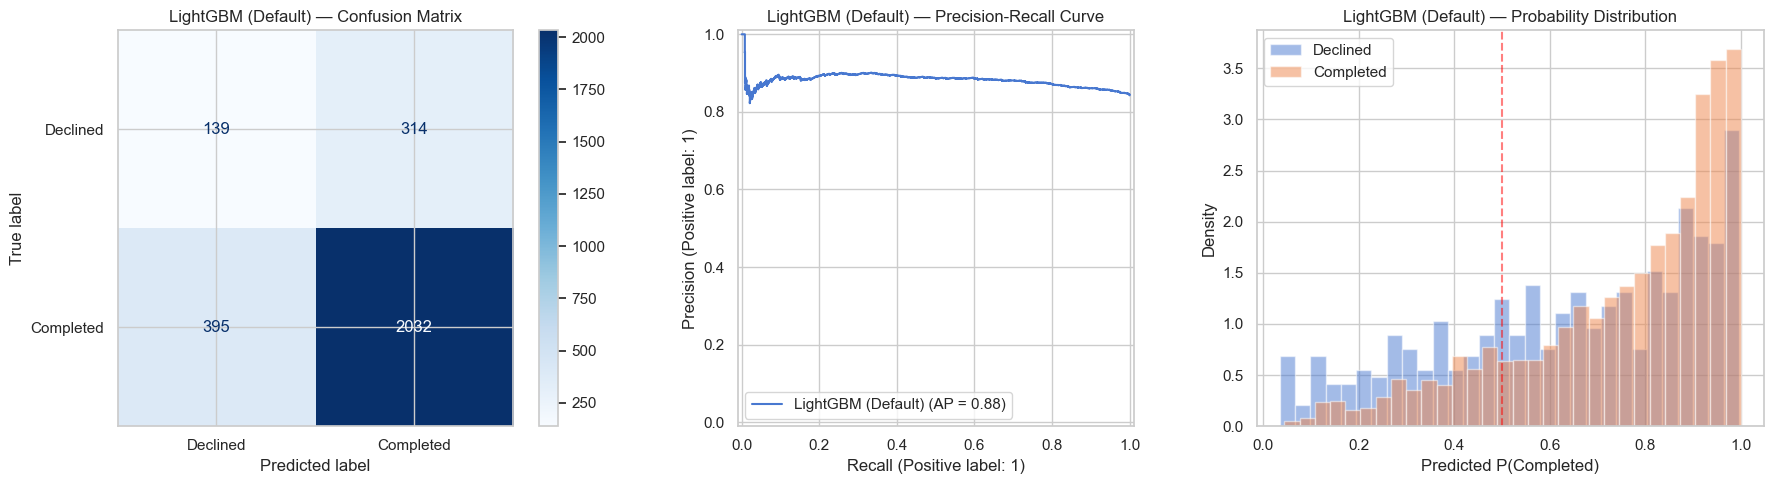

In [12]:
plot_evaluation(lgb_default_results, 'LightGBM (Default)')

---
## 6. Model B — LightGBM + Optuna Hyperparameter Tuning

In [13]:
def lgb_objective(trial):
    """Optuna objective for LightGBM — maximize F1 macro on stratified CV."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    
    f1_scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        f1_scores.append(f1_score(y_val, y_pred, average='macro'))
    
    return np.mean(f1_scores)

In [14]:
study = optuna.create_study(direction='maximize', study_name='lgb_claim_approval')
study.optimize(lgb_objective, n_trials=80, show_progress_bar=True)

print(f'\nBest trial:')
print(f'  F1 (macro): {study.best_value:.4f}')
print(f'  Params:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

  0%|          | 0/80 [00:00<?, ?it/s]


Best trial:
  F1 (macro): 0.5526
  Params:
    n_estimators: 700
    max_depth: 7
    learning_rate: 0.29423603681798954
    num_leaves: 45
    min_child_samples: 58
    scale_pos_weight: 2.136014967261392
    reg_alpha: 0.001094325292522119
    reg_lambda: 0.003439808163294217
    subsample: 0.8530618947419231
    colsample_bytree: 0.844524873165252


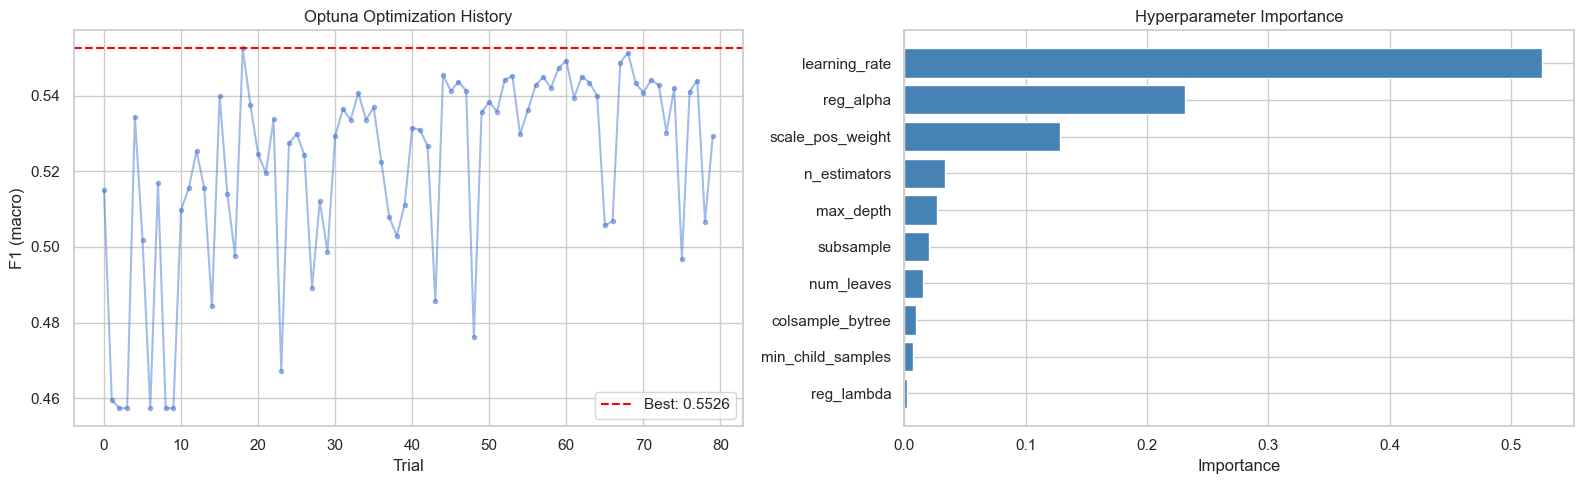

In [15]:
# Optuna visualization — parameter importance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trials = study.trials
values = [t.value for t in trials if t.value is not None]
axes[0].plot(values, 'o-', alpha=0.5, markersize=3)
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1 (macro)')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

# Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importances.items(), key=lambda x: x[1])
    axes[1].barh([p[0] for p in params_sorted], [p[1] for p in params_sorted], color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
except:
    axes[1].text(0.5, 0.5, 'Could not compute param importance', ha='center', va='center')

plt.tight_layout()
plt.show()

In [16]:
# Evaluate tuned LightGBM
lgb_tuned = lgb.LGBMClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_tuned_results = evaluate_cv(lgb_tuned, X, y, model_name='LightGBM (Tuned)')


LightGBM (Tuned) — 5-Fold Stratified CV Results

Per-fold metrics:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.587743     0.270677 0.871559 0.608573
    2  0.521387     0.158273 0.863038 0.561511
    3  0.626984     0.347222 0.902064 0.678917
    4  0.513364     0.137405 0.879790 0.599773
    5  0.513364     0.137405 0.888817 0.607772

Mean +/- Std:
  f1_macro       : 0.5526 +/- 0.0520
  f1_declined    : 0.2102 +/- 0.0945
  pr_auc         : 0.8811 +/- 0.0151
  roc_auc        : 0.6113 +/- 0.0424

Aggregate Classification Report (all folds):
              precision    recall  f1-score   support

    Declined       0.32      0.16      0.21       453
   Completed       0.86      0.94      0.89      2427

    accuracy                           0.81      2880
   macro avg       0.59      0.55      0.55      2880
weighted avg       0.77      0.81      0.79      2880



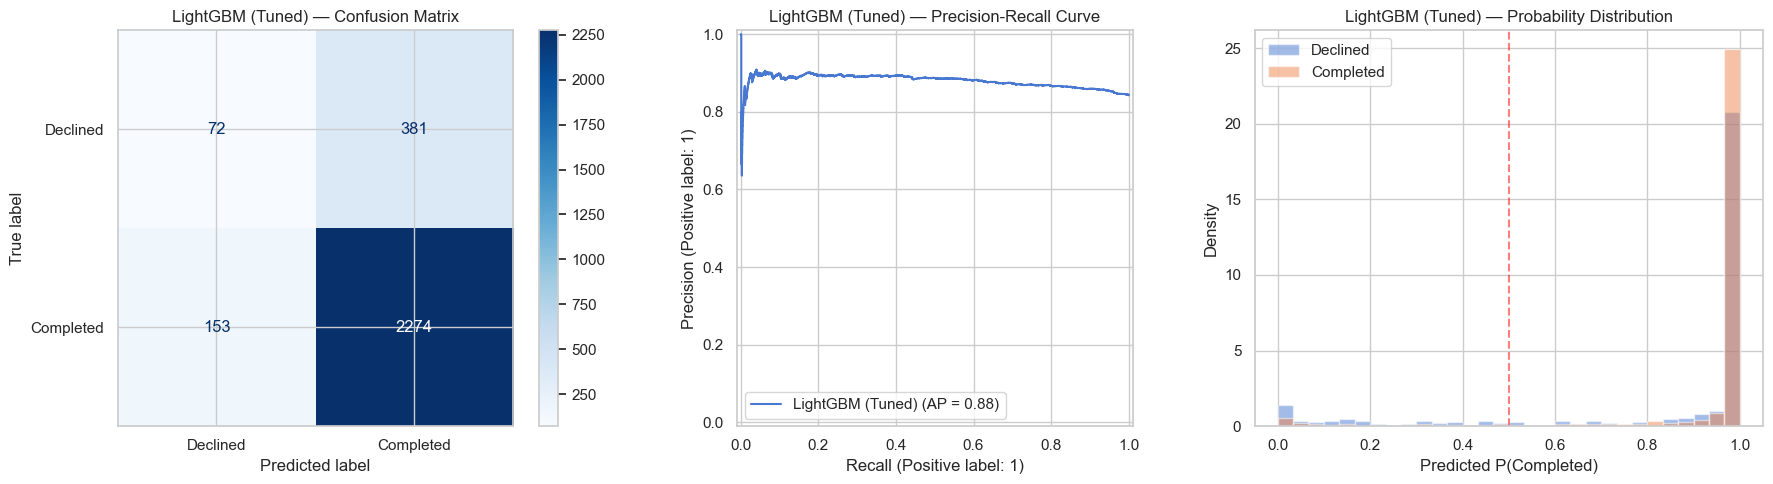

In [17]:
plot_evaluation(lgb_tuned_results, 'LightGBM (Tuned)')

---
## 7. Model C — XGBoost (Comparison)

In [18]:
xgb_model = xgb.XGBClassifier(
    n_estimators=study.best_params.get('n_estimators', 500),
    max_depth=study.best_params.get('max_depth', 5),
    learning_rate=study.best_params.get('learning_rate', 0.05),
    scale_pos_weight=study.best_params.get('scale_pos_weight', 5.0),
    reg_alpha=study.best_params.get('reg_alpha', 0.1),
    reg_lambda=study.best_params.get('reg_lambda', 1.0),
    subsample=study.best_params.get('subsample', 0.8),
    colsample_bytree=study.best_params.get('colsample_bytree', 0.8),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
)

xgb_results = evaluate_cv(xgb_model, X, y, model_name='XGBoost')


XGBoost — 5-Fold Stratified CV Results

Per-fold metrics:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.565043     0.229008 0.885149 0.612437
    2  0.537854     0.176000 0.865012 0.578384
    3  0.582269     0.259542 0.908853 0.685023
    4  0.534884     0.166667 0.886500 0.615203
    5  0.545242     0.195489 0.902369 0.641282

Mean +/- Std:
  f1_macro       : 0.5531 +/- 0.0201
  f1_declined    : 0.2053 +/- 0.0386
  pr_auc         : 0.8896 +/- 0.0171
  roc_auc        : 0.6265 +/- 0.0396

Aggregate Classification Report (all folds):
              precision    recall  f1-score   support

    Declined       0.35      0.15      0.21       453
   Completed       0.86      0.95      0.90      2427

    accuracy                           0.82      2880
   macro avg       0.60      0.55      0.55      2880
weighted avg       0.78      0.82      0.79      2880



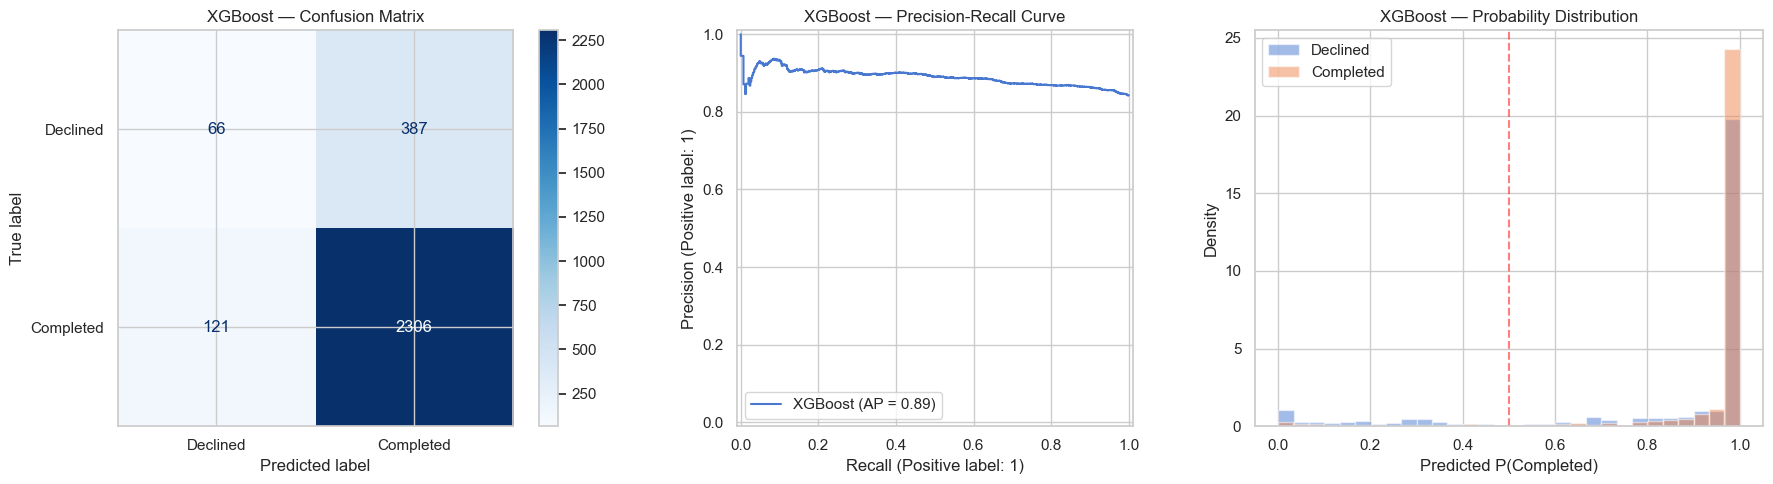

In [19]:
plot_evaluation(xgb_results, 'XGBoost')

---
## 8. Model Comparison

In [20]:
# Compare all models side by side
all_results = {
    'Logistic Regression': lr_results,
    'LightGBM (Default)': lgb_default_results,
    'LightGBM (Tuned)': lgb_tuned_results,
    'XGBoost': xgb_results,
}

comparison = []
for name, res in all_results.items():
    mdf = res['metrics_df']
    comparison.append({
        'Model': name,
        'F1 Macro (mean)': mdf['f1_macro'].mean(),
        'F1 Macro (std)': mdf['f1_macro'].std(),
        'F1 Declined (mean)': mdf['f1_declined'].mean(),
        'PR-AUC (mean)': mdf['pr_auc'].mean(),
        'ROC-AUC (mean)': mdf['roc_auc'].mean(),
    })

comparison_df = pd.DataFrame(comparison).set_index('Model')
comparison_df = comparison_df.round(4)

print('Model Comparison Summary:')
print(comparison_df.to_string())

Model Comparison Summary:
                     F1 Macro (mean)  F1 Macro (std)  F1 Declined (mean)  PR-AUC (mean)  ROC-AUC (mean)
Model                                                                                                  
Logistic Regression           0.5188          0.0191              0.3033         0.8942          0.6241
LightGBM (Default)            0.5657          0.0304              0.2800         0.8837          0.6216
LightGBM (Tuned)              0.5526          0.0520              0.2102         0.8811          0.6113
XGBoost                       0.5531          0.0201              0.2053         0.8896          0.6265


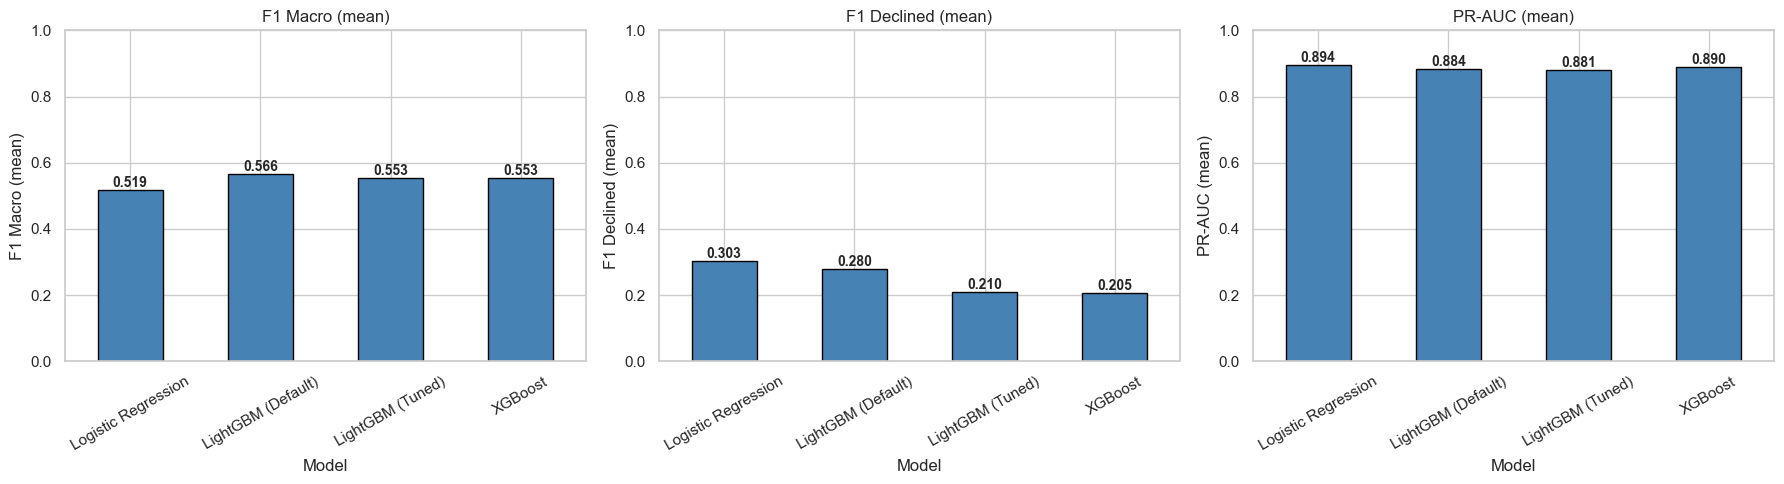

In [21]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['F1 Macro (mean)', 'F1 Declined (mean)', 'PR-AUC (mean)']
for ax, metric in zip(axes, metrics_to_plot):
    comparison_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Select best model based on F1 Macro
best_model_name = comparison_df['F1 Macro (mean)'].idxmax()
print(f'Best model: {best_model_name}')
print(f'  F1 Macro: {comparison_df.loc[best_model_name, "F1 Macro (mean)"]:.4f}')
print(f'  F1 Declined: {comparison_df.loc[best_model_name, "F1 Declined (mean)"]:.4f}')
print(f'  PR-AUC: {comparison_df.loc[best_model_name, "PR-AUC (mean)"]:.4f}')

Best model: LightGBM (Default)
  F1 Macro: 0.5657
  F1 Declined: 0.2800
  PR-AUC: 0.8837


---
## 9. Threshold Optimization

The default 0.5 threshold may not be optimal for imbalanced data. We find the threshold that maximizes F1 for the Declined class on the aggregated CV predictions.

In [23]:
# Use the tuned LightGBM predictions for threshold optimization
best_results = lgb_tuned_results

y_true = best_results['y_true']
y_proba = best_results['y_proba']

# Search for optimal threshold
thresholds = np.arange(0.1, 0.9, 0.01)
f1_macros = []
f1_declineds = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_macros.append(f1_score(y_true, y_pred_t, average='macro'))
    f1_declineds.append(f1_score(y_true, y_pred_t, pos_label=0))

best_thresh_macro = thresholds[np.argmax(f1_macros)]
best_thresh_declined = thresholds[np.argmax(f1_declineds)]

print(f'Optimal threshold for F1 Macro:    {best_thresh_macro:.2f} (F1={max(f1_macros):.4f})')
print(f'Optimal threshold for F1 Declined: {best_thresh_declined:.2f} (F1={max(f1_declineds):.4f})')
print(f'Default threshold (0.50):          F1 Macro={f1_score(y_true, (y_proba >= 0.5).astype(int), average="macro"):.4f}')

Optimal threshold for F1 Macro:    0.74 (F1=0.5639)
Optimal threshold for F1 Declined: 0.89 (F1=0.2555)
Default threshold (0.50):          F1 Macro=0.5537


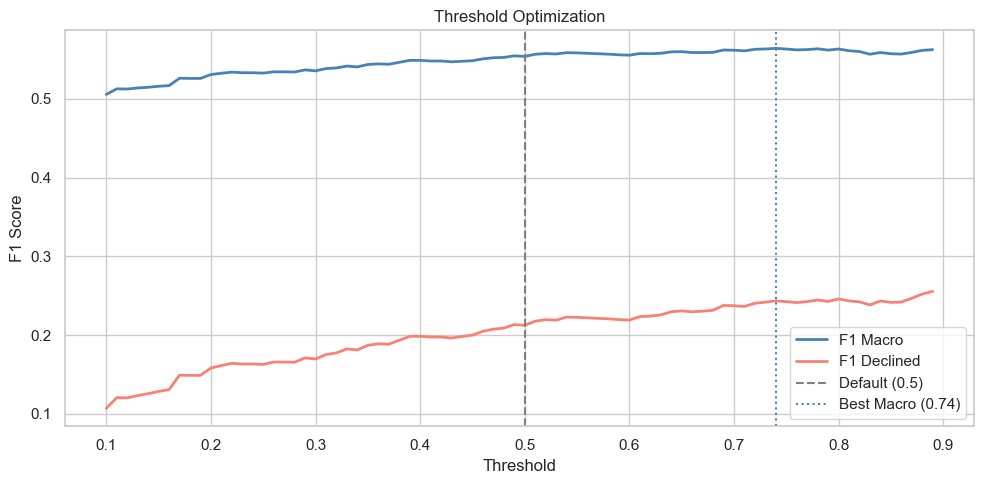

In [24]:
# Visualize threshold effect
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_macros, label='F1 Macro', color='steelblue', linewidth=2)
ax.plot(thresholds, f1_declineds, label='F1 Declined', color='salmon', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
ax.axvline(x=best_thresh_macro, color='steelblue', linestyle=':', label=f'Best Macro ({best_thresh_macro:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Optimization')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Classification report with optimized threshold
optimal_threshold = best_thresh_macro
y_pred_optimized = (y_proba >= optimal_threshold).astype(int)

print(f'Classification Report with Optimized Threshold ({optimal_threshold:.2f}):')
print(classification_report(y_true, y_pred_optimized, target_names=['Declined', 'Completed']))

print(f'\nCompare with Default Threshold (0.50):')
y_pred_default = (y_proba >= 0.5).astype(int)
print(classification_report(y_true, y_pred_default, target_names=['Declined', 'Completed']))

Classification Report with Optimized Threshold (0.74):
              precision    recall  f1-score   support

    Declined       0.30      0.21      0.24       453
   Completed       0.86      0.91      0.88      2427

    accuracy                           0.80      2880
   macro avg       0.58      0.56      0.56      2880
weighted avg       0.77      0.80      0.78      2880


Compare with Default Threshold (0.50):
              precision    recall  f1-score   support

    Declined       0.32      0.16      0.21       453
   Completed       0.86      0.94      0.89      2427

    accuracy                           0.81      2880
   macro avg       0.59      0.55      0.55      2880
weighted avg       0.77      0.81      0.79      2880



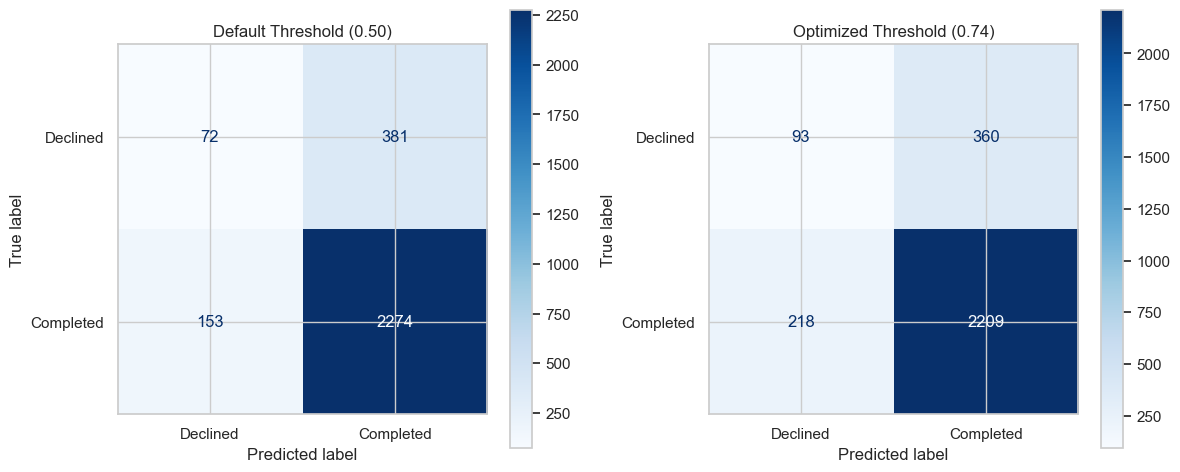

In [26]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_default),
    display_labels=['Declined', 'Completed']
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Default Threshold (0.50)')

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_optimized),
    display_labels=['Declined', 'Completed']
).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Optimized Threshold ({optimal_threshold:.2f})')

plt.tight_layout()
plt.show()

---
## 10. Feature Importance — LightGBM Native

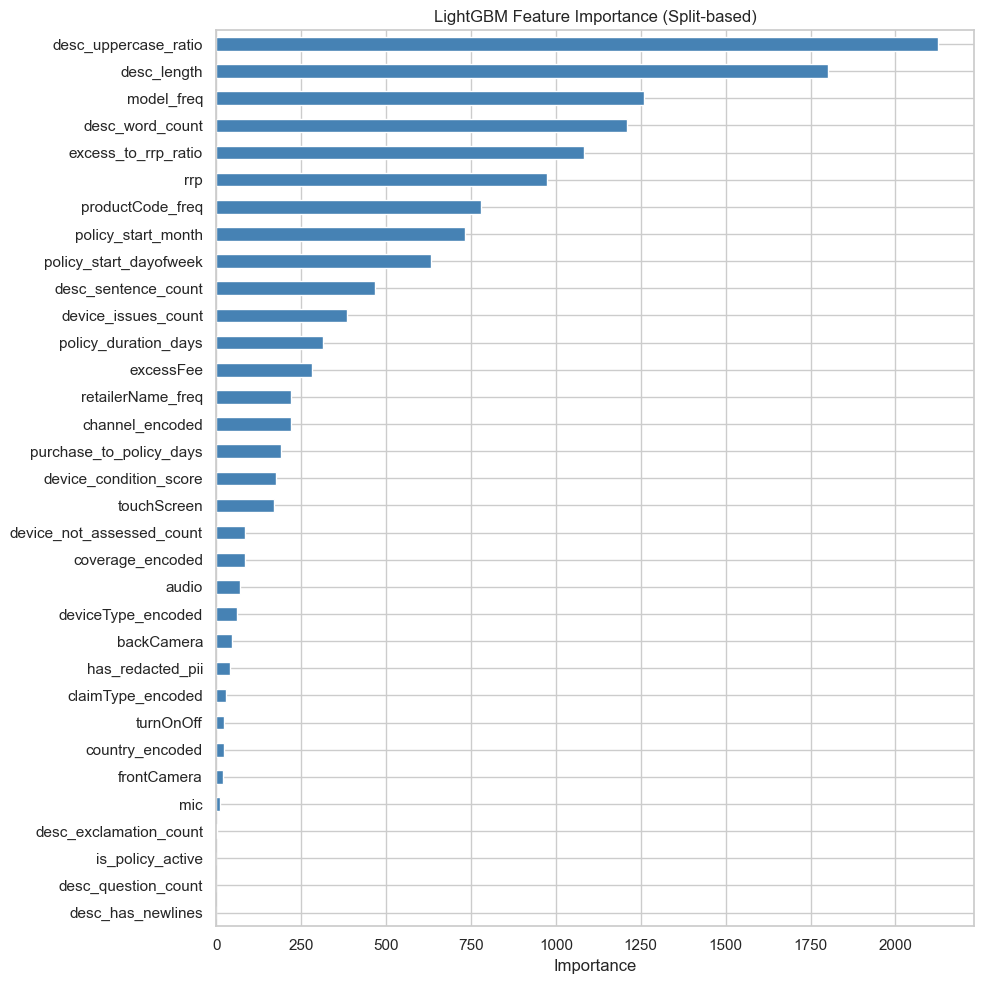

In [27]:
# Train final model on full data
final_model = lgb.LGBMClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
final_model.fit(X, y)

# Native feature importance (gain)
importance = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM Feature Importance (Split-based)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 11. SHAP Explainability

In [28]:
# Compute SHAP values using TreeExplainer (exact for tree models)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# For binary classification, shap_values may be a list [class_0, class_1] or a single array
if isinstance(shap_values, list):
    # Use SHAP values for the positive class (Completed=1)
    shap_vals = shap_values[1]
    print(f'SHAP values shape (class 1): {shap_vals.shape}')
else:
    shap_vals = shap_values
    print(f'SHAP values shape: {shap_vals.shape}')

SHAP values shape: (2880, 33)


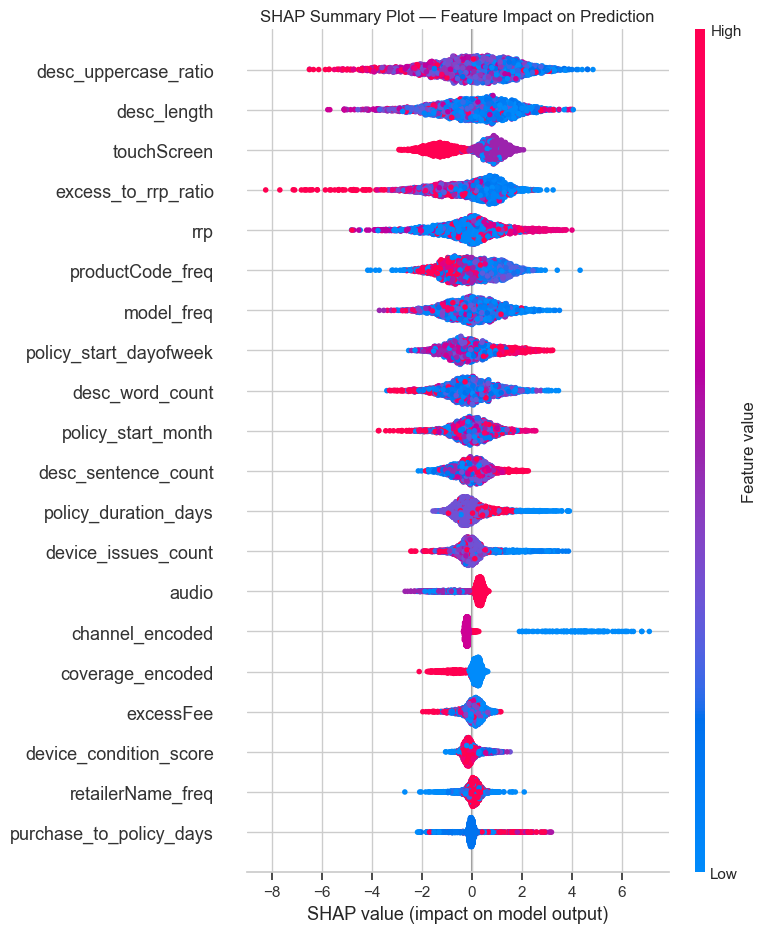

In [29]:
# SHAP summary plot (beeswarm)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Prediction')
plt.tight_layout()
plt.show()

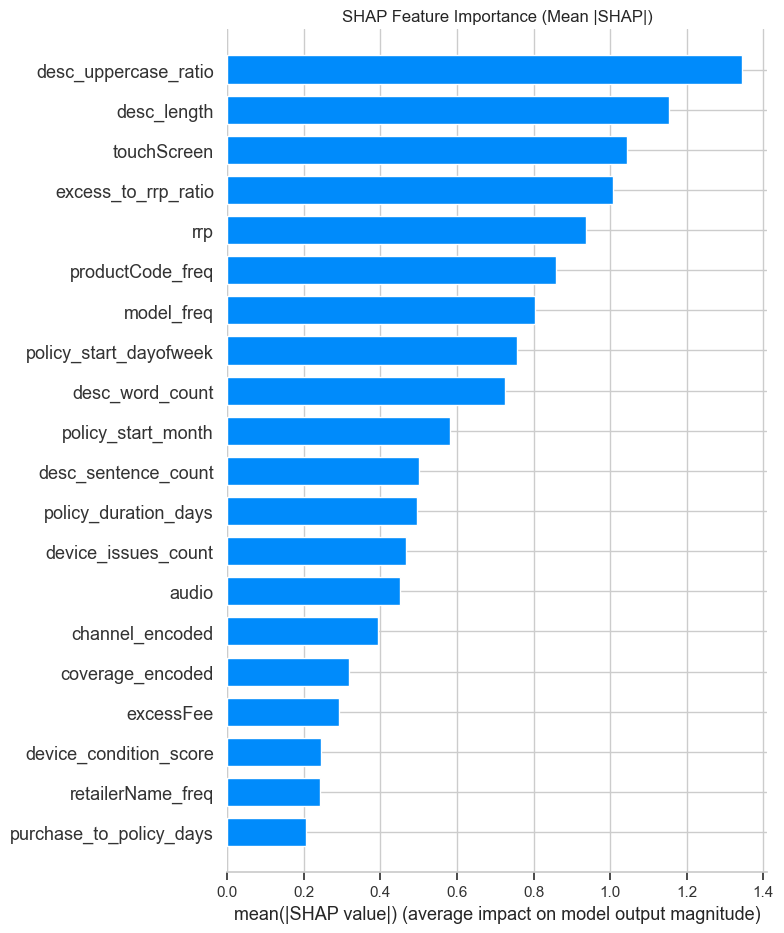

In [30]:
# SHAP bar plot (mean absolute SHAP value)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X, feature_names=feature_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.show()

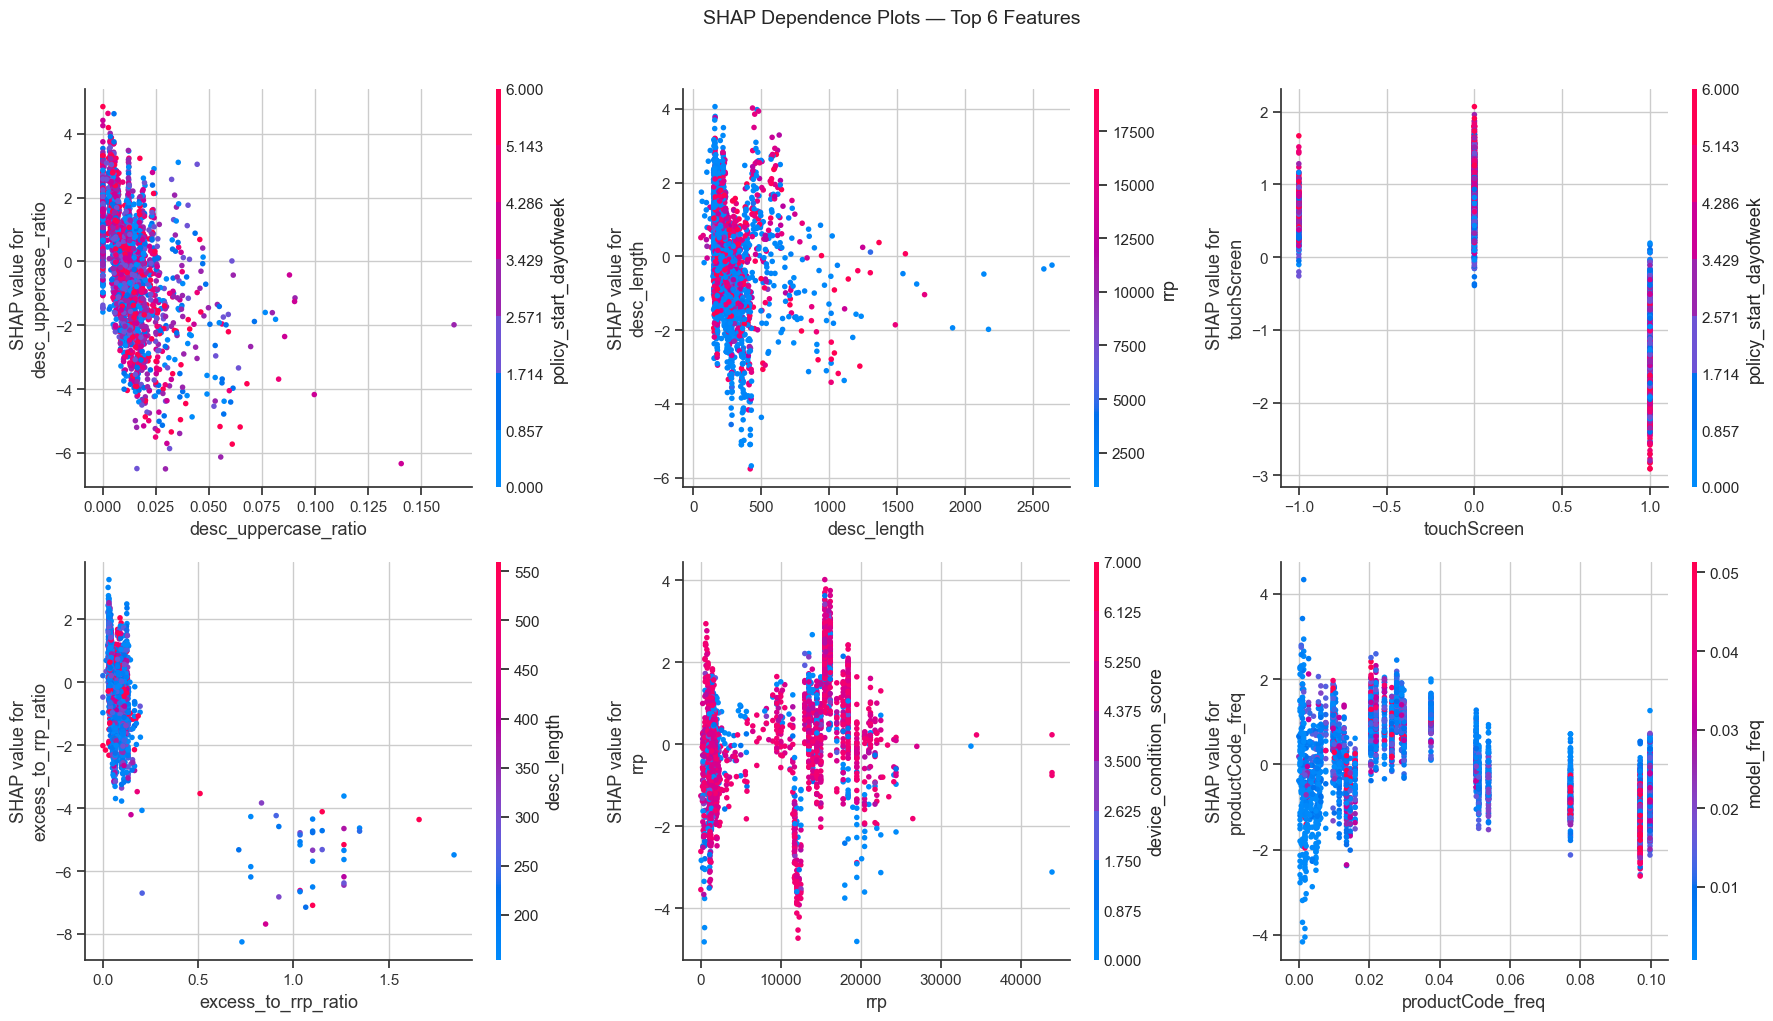

In [31]:
# SHAP dependence plots for top features
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[::-1][:6]
top_feature_names = [feature_cols[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat_name in zip(axes.flat, top_feature_names):
    feat_idx = feature_cols.index(feat_name)
    shap.dependence_plot(feat_idx, shap_vals, X, feature_names=feature_cols, ax=ax, show=False)

plt.suptitle('SHAP Dependence Plots — Top 6 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Explaining claim index 13 (actual: Declined)
Model prediction probability: [0.99749906 0.00250094]


<Figure size 1400x400 with 0 Axes>

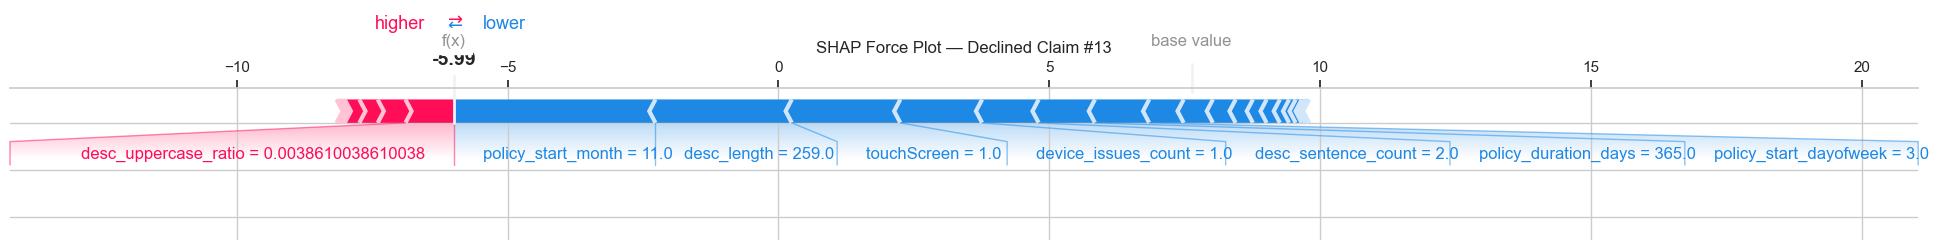

In [32]:
# Example: explain a single DECLINED claim
declined_indices = np.where(y == 0)[0]
sample_idx = declined_indices[0]

print(f'Explaining claim index {sample_idx} (actual: {"Completed" if y[sample_idx] == 1 else "Declined"})')
print(f'Model prediction probability: {final_model.predict_proba(X[sample_idx:sample_idx+1])[0]}')

plt.figure(figsize=(14, 4))
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_vals[sample_idx],
    X[sample_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Declined Claim #{sample_idx}')
plt.tight_layout()
plt.show()

Explaining claim index 0 (actual: Completed)
Model prediction probability: [1.64219061e-04 9.99835781e-01]


<Figure size 1400x400 with 0 Axes>

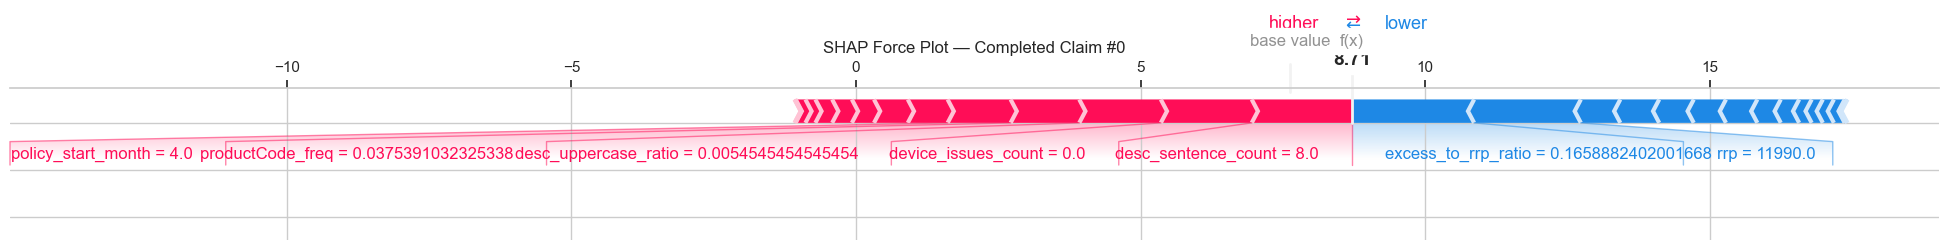

In [33]:
# Example: explain a single COMPLETED claim
completed_indices = np.where(y == 1)[0]
sample_idx = completed_indices[0]

print(f'Explaining claim index {sample_idx} (actual: {"Completed" if y[sample_idx] == 1 else "Declined"})')
print(f'Model prediction probability: {final_model.predict_proba(X[sample_idx:sample_idx+1])[0]}')

plt.figure(figsize=(14, 4))
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_vals[sample_idx],
    X[sample_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Completed Claim #{sample_idx}')
plt.tight_layout()
plt.show()

---
## 12. Save Artifacts

In [34]:
output_dir = Path('../../models')
output_dir.mkdir(exist_ok=True)

# 1. Save the final trained model
joblib.dump(final_model, output_dir / 'lgb_claim_model.joblib')
print(f'Saved model to {output_dir / "lgb_claim_model.joblib"}')

# 2. Save SHAP values for the GenAI explanation pipeline
shap_df = pd.DataFrame(shap_vals, columns=feature_cols)
shap_df.to_csv(output_dir / 'shap_values.csv', index=False)
print(f'Saved SHAP values to {output_dir / "shap_values.csv"}')

# 3. Save feature list and optimal threshold
with open(output_dir / 'model_config.txt', 'w') as f:
    f.write(f'optimal_threshold={optimal_threshold}\n')
    f.write(f'feature_columns={"|".join(feature_cols)}\n')
    f.write(f'model_type=LightGBM\n')
    f.write(f'best_f1_macro={comparison_df.loc["LightGBM (Tuned)", "F1 Macro (mean)"]:.4f}\n')
print(f'Saved config to {output_dir / "model_config.txt"}')

# 4. Save the comparison table
comparison_df.to_csv(output_dir / 'model_comparison.csv')
print(f'Saved comparison to {output_dir / "model_comparison.csv"}')

# 5. Save Optuna study best params
import json
with open(output_dir / 'best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)
print(f'Saved best params to {output_dir / "best_params.json"}')

Saved model to ..\..\models\lgb_claim_model.joblib
Saved SHAP values to ..\..\models\shap_values.csv
Saved config to ..\..\models\model_config.txt
Saved comparison to ..\..\models\model_comparison.csv
Saved best params to ..\..\models\best_params.json


---
## Wrap up

Results are honestly not great. Best model is LightGBM default with F1 macro 0.566, F1 declined only 0.28. The model barely catches declined claims.

The main issue is we're not using the text content at all - just surface stats like word count. The issueDesc column is probably the most informative feature in the dataset and we're ignoring what it actually says.

Saved the model, SHAP values, and comparison table to `models/`. Next step is adding text embeddings to see if that helps.